In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)


(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

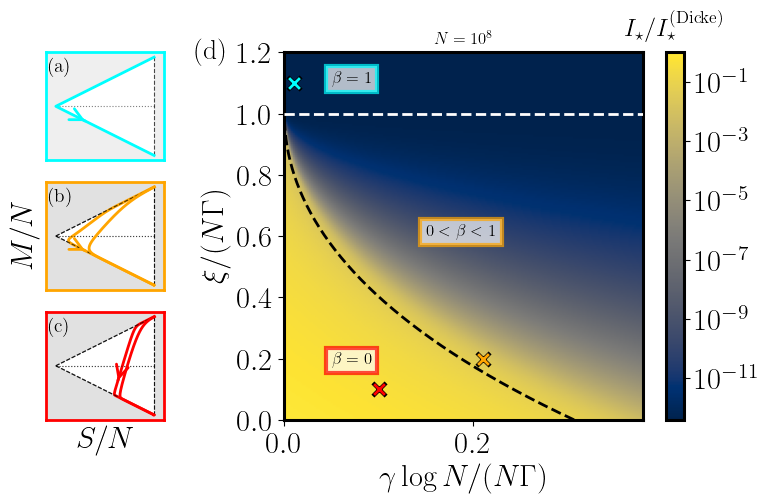

In [ ]:
function generate_spont_phase_diagram_data(;
    outfile = "../plot_data/spont_phase_diagram.jld2",
    gs = range(0.0, 0.38, 200),
    rs = range(0.0, 1.2, 200),
    pow = 200,
    reltol = 1e-8,
    abstol = 1e-10,
)
    N = BigInt(10)^pow
    Nf = Float64(N)

    data = zeros(length(rs), length(gs))

    for (i, r) in enumerate(rs)
        for (j, g) in enumerate(gs)
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]
            t_end = 100.0 * log(Nf) / Nf

            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol = reltol,
                abstol = abstol,
                saveat = range(0.0, t_end, 30000)
            )

            data[i, j] = exp(maximum(x -> x[1], sol.u))
        end
    end

    jldsave(outfile;
        gs = collect(gs),
        rs = collect(rs),
        data = data,
        pow = pow,
        N = string(N),
    )
end

function analytic_spont_boundary(rs)
    return (1 .- rs) .- (1 .+ rs) .* log.(2 ./ (1 .+ rs))
end

function plot_spont_phase_diagram!(
    ax,
    d;
    contour_tol = 1e-2,
    show_analytic_boundary = true,
    rescale_intensity = 4.0,
    cmap = "viridis",
    add_colorbar = true,
    colorbar_label = L"$I/N^2$",
    analytic_color = "white",
    analytic_linestyle = "--",
)
    gs = d["gs"]
    rs = d["rs"]
    data = d["data"]

    norm = matplotlib.colors.LogNorm(
    vmin = maximum([minimum(rescale_intensity .* data), contour_tol]),
    vmax = maximum(rescale_intensity .* data)
    )

    im = ax.imshow(
        rescale_intensity .* data,
        extent = [first(gs), last(gs), first(rs), last(rs)],
        origin = "lower",
        aspect = "auto",
        cmap = cmap,
        norm = norm
            )

    if show_analytic_boundary
        rb = collect(rs)
        gb = analytic_spont_boundary(rb)
        valid = (gb .>= minimum(gs)) .& (gb .<= maximum(gs)) .& (rs .< 1.0)
        ax.plot(gb[valid], rb[valid], color = "black", linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=0\text{ boundary}")

        y = similar(gs); y .= 1.0
        ax.plot(gs, y, color = analytic_color, linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=1\text{ boundary}")
        bbox = Dict("facecolor" => "white", "edgecolor" => "red", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.05, 0.18, L"\beta=0", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "orange", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.15, 0.6, L"0<\beta<1", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "cyan", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.05, 1.1, L"\beta=1", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
    end

    clb = colorbar(im, ax = ax)
    ax.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax.set_ylabel(L"\xi/(N\Gamma)")
    clb.ax.set_title(L"I_\star/I_\star^{\rm(Dicke)}", pad = 12, fontsize = 18)
end

function plot_mf_trajectory!(ax;
    N = 10^8,
    gbar = 0.0,
    color = "red",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0,
    arrow=true,
    linestyle="solid"
)

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.plot([0.5, 0.5], [-0.5, 0.5]; color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    tmax = c * log(N) / N

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => gbar * N / log(N),
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle=linestyle,
            label=L"\bar g_\gamma = %$gbar"
        )

        i = argmin(abs.(Mnorm .+ 0.15))

        if arrow
        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
        end

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    patches = pyimport("matplotlib.patches")
    path_mod = pyimport("matplotlib.path")

    pad = 0.3
    verts = [
        (-pad, -0.5-pad), (0.5+pad, -0.5-pad), (0.5+pad, 0.5+pad), (-pad, 0.5+pad),
        (0.0, 0.0),
        (0.5, 0.5), (0.5, -0.5), (0.0, 0.0)
    ]
    codes = [
        path_mod.Path.MOVETO, path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.LINETO,
        path_mod.Path.MOVETO,
        path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.CLOSEPOLY
    ]
    p = path_mod.Path(verts, codes)
    patch = patches.PathPatch(p, facecolor="gray", alpha=triangle_alpha, edgecolor="none", zorder=0)
    ax.add_patch(patch)

        
    ax.set_xticks([])
    ax.set_yticks([])

    return ax
end

function shade_low_intensity_region!(
    ax;
    Ithresh = 0.02,
    ns = 1000,
    color = "gray",
    alpha = 0.25,
    zorder = 1,
)
    smax = 0.5
    svals = collect(range(0.0, smax; length = ns))

    # Region is |m| <= s, with intensity I = s^2 - m^2.
    # Low-intensity condition: s^2 - m^2 <= Ithresh
    #
    # For s^2 <= Ithresh, the entire vertical slice -s <= m <= s is low intensity.
    # For s^2 > Ithresh, only near m = ±s is low intensity.

    slow = sqrt(Ithresh)

    # Tip region: entire triangle slice is below threshold
    mask_tip = svals .<= slow
    if any(mask_tip)
        stip = svals[mask_tip]
        ax.fill_between(
            stip,
            -stip,
            stip;
            color = color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )
    end

    # Boundary layers: only near upper/lower Dicke edges
    mask_layer = svals .> slow
    if any(mask_layer)
        slayer = svals[mask_layer]
        minner = sqrt.(slayer.^2 .- Ithresh)

        # upper layer: minner <= m <= s
        ax.fill_between(
            slayer,
            minner,
            slayer;
            color = color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )

        # lower layer: -s <= m <= -minner
        ax.fill_between(
            slayer,
            -slayer,
            -minner;
            color = color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )
    end

    return ax
end

data = load("../plot_data/spont_phase_diagram_13.jld2")
#fig, ax = subplots(figsize = latex_plot_setup(scale = 1, ratio = 0.9, fraction = 1, font_size_pt = 11))

w,h = latex_plot_setup(scale = 2, ratio = 1.0, font_size_pt = 11)
fig = figure(figsize = (2 * w, h))
gs = fig.add_gridspec(3, 2, width_ratios = [1, 2])

ax1 = fig.add_subplot(gs[1, 1])  # top-left triangle
ax2 = fig.add_subplot(gs[2, 1])  # middle triangle
ax3 = fig.add_subplot(gs[3, 1])  # bottom triangle
sub = py"$gs[0:3, 1]"
ax4 = fig.add_subplot(sub)  # right column, full height

Ntraj = 10^8
N2 = 500
pt = [0.1,0.1]
plot_mf_trajectory!(ax3; gbar = pt[1], r = pt[2], N = Ntraj, color = "red")
plot_mf_trajectory!(ax3; gbar = pt[1], r = pt[2], N = N2, color = "red", arrow = false)
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="red", s=60, linewidths=2, zorder=12)
pt = (0.21, 0.2)
x0 = -0.133

plot_mf_trajectory!(ax2; gbar = pt[1], r = pt[2], N = Ntraj, color = "orange")
plot_mf_trajectory!(ax2; gbar = pt[1], r = pt[2], N = N2, color = "orange", arrow = false)
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="orange", s=60, linewidths=2, zorder=12)
pt = (0.01, 1.1)
x0 = -0.133

plot_mf_trajectory!(ax1; gbar = pt[1], r = pt[2], N = Ntraj, color = "cyan")
#plot_mf_trajectory!(ax1; gbar = pt[1], r = pt[2], N = N2, color = "cyan")
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="cyan", s=60, linewidths=2, zorder=12)

ax1.set_aspect(0.5)
ax2.set_aspect(0.5)
ax3.set_aspect(0.5)

#shade_low_intensity_region!(ax1; Ithresh = 0.02, alpha = 0.25)
#shade_low_intensity_region!(ax2; Ithresh = 0.02, alpha = 0.25)
#shade_low_intensity_region!(ax3; Ithresh = 0.02, alpha = 0.25)

pad = 0.05
for ax in (ax1, ax2, ax3)
    ax.set_xlim(-pad, 0.5 + pad)
    ax.set_ylim(-0.5 - pad, 0.5 + pad)
end

for (ax_tri, color) in zip([ax1, ax2, ax3], ["cyan", "orange", "red"])
    for spine in ax_tri.spines.values()
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    end
end

#ax1.set_ylabel(L"M/N", fontsize = 15)
ax2.set_ylabel(L"M/N")
#ax3.set_ylabel(L"M/N", fontsize = 15)
ax3.set_xlabel(L"S/N")

plot_spont_phase_diagram!(ax4, data; contour_tol = 1e-13, cmap = "cividis")
#ax4.legend(;legend_kwargs...)

for (ax_tri, label) in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"])
    ax_tri.text(0.02, 0.95, label, transform=ax_tri.transAxes, fontsize=14, fontweight="bold", va="top")
end

ax4.text(-0.25, 1.04, "(d)", transform=ax4.transAxes, fontsize=20, fontweight="bold", va="top")
ax4.set_title(L"N=10^8", fontsize = legend_kwargs.fontsize)

savefig("../data/fig3.pdf", bbox_inches = "tight")